In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# imports
from pathlib import Path
import sys  

# Get my_package directory path from Notebook
parent_dir = str(Path().resolve().parents[0])

# Add to sys.path
sys.path.insert(0, parent_dir)


In [3]:
from utils.experiment_utils import get_all_experiments_info, load_best_model

device = 'cuda'
configs = get_all_experiments_info('../outputs/', False)
cfgs = [
    c for c in configs if 'handwriting' in c['name'] 
    and c['config']['training']['num_epochs'] == 5000
]   


In [4]:
import hydra
# load + prep dataset
def prepare_dataset(dataset_cfg):
    # probs = np.column_stack((np.linspace(0, 1, num_probs), 1 - np.linspace(0, 1, num_probs)))
    dataset = hydra.utils.instantiate(dataset_cfg)
    # dataset.probs = probs
    # dataset.data, _, _ = dataset.make_sets()
    return dataset

# load encoder and move to device
def load_model(cfg, path, device):
    enc = hydra.utils.instantiate(cfg['encoder'])
    gen = hydra.utils.instantiate(cfg['generator'])
    state = load_best_model(path)
    enc.load_state_dict(state['encoder_state_dict'])
    gen.load_state_dict(state['generator_state_dict'])
    enc.eval()
    gen.eval()
    enc.to(device)
    gen.to(device)
    return enc, gen

enc, gen = load_model(cfgs[0]['config'], cfgs[0]['dir'], device)

In [5]:
ds = prepare_dataset(cfgs[0]['config']['dataset'])

In [6]:
batch = next(iter(ds))

In [7]:
import numpy as np
import torch
source_samples = batch['source_samples']
target_samples = batch['target_samples']
source_latent, target_latent = enc(
    torch.from_numpy(np.concatenate([source_samples[None, ...], target_samples[None, ...]], axis=0)).float().to(device)
)

resample = gen.sample(source_samples.to(device), source_latent.unsqueeze(0), target_latent.unsqueeze(0)).squeeze(0)

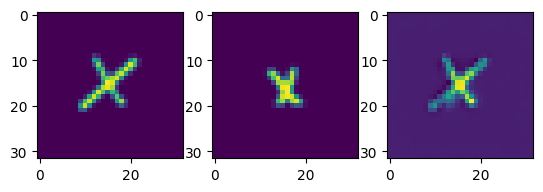

In [9]:
import matplotlib.pyplot as plt
# visualize 3 channel image
source_samples = batch['source_samples']
target_samples = batch['target_samples']
i = -11
fig, axs = plt.subplots(1, 3)
axs[0].imshow(source_samples[i].cpu().numpy().transpose(1, 2, 0))
axs[1].imshow(target_samples[i].cpu().numpy().transpose(1, 2, 0))
axs[2].imshow(resample[i].cpu().numpy().transpose(1, 2, 0))
plt.show()